# SPEED workflow (stage 2/2): Train on the spatial epigenomic data based on prior information from single-cell data

Dataset: The mouse embryo MISAR-seq dataset by Jiang et al ([here](https://zenodo.org/))

In [1]:
import os
import sys
adata_input_path = 'spATAC/MISAR/ME11_0_S1.h5ad'
pretrain_input_path = 'pretrained/mouse_embryo.h5ad'
adata_output_path = './MISAR_out'

In [2]:
import SPEED
import scanpy as sc

/home/lifesci/wangshuyan/miniconda3/envs/pytorch/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## load the data

load the spatial epigenomic data and the corresponding single-cell data. Please ensure that there is an overlap between the peak sets of them. The single-cell data has already undergone training in the first stage. The trained single-cell peak embedding is stored in `adata_sc.varm[peak_name]`.

In [3]:
adata = sc.read(adata_input_path)
adata_sc = sc.read(pretrain_input_path)

Process spatial and single-cell epigenomics data by selecting common features.

In [4]:
adata,adata_sc = SPEED.process(adata,adata_sc)

Extract RGB-format image data from the adata dataset.

In [5]:
img = adata.uns['spatial']['ME11_0_S1']['images']['lowres']

## initialize the SPEED model

initialize the model with spatial data and pre-trained single-cell data. 

`k_degree` is the degree of spatial neighbor used for spatial relative position encoding. For data with a 50 μm resolution, k is defaulted to 5.

`is_spatial` is set to `True` during the second stage of training on spatial data.

In [6]:
speed = SPEED.SPEED(adata,image=img,k_degree=5, is_spatial=True, adata_sc=adata_sc)

matrix ready...
use 0-1 matrix...
cell_features ready...
peak features ready...
segment the image into spots...
image encoding...


100%|██████████| 1263/1263 [00:01<00:00, 680.80it/s]


In [7]:
speed.img.shape

(1263, 2048)

In [8]:
speed.setup_data(num_workers=4)

split ready...
labels ready...
peak embedding is given
dataset ready...


`num_workers` is the number of subprocesses for data loading

In [9]:
speed.build_model(emb_features=32)

`emb_features` is the number of embedding features

## Train the SPEED model

In [ ]:
speed.train(lr=1e-5, device='cpu')

In [11]:
torch.save(speed.model.state_dict(), f'MISAR_out/model.pth')

## Get the results

Use `SPEED.SPEED.get_embedding` to get the low-dimensional embedding.

The spot/cell embeddings will be stored in `adata.obsm['X_SPEED']`. The peak embeddings will be stored in `adata.varm['peak_SPEED']`

In [12]:
adata = speed.get_embedding(adata)

get cell/spot embedding...


100%|██████████| 5/5 [00:00<00:00, 16.26it/s]


get peak embedding...


100%|██████████| 5/5 [00:00<00:00, 11.39it/s]


get spatial embedding...


Use SPEED.SPEED.get_denoise_result to get the denoised matrix.

In [13]:
adata.X = speed.get_denoise_result()

In [14]:
sc.pp.neighbors(adata, use_rep='X_SPEED', random_state=1)
sc.tl.umap(adata)
sc.tl.leiden(adata, random_state=1, key_added="leiden_spot",resolution=0.5)

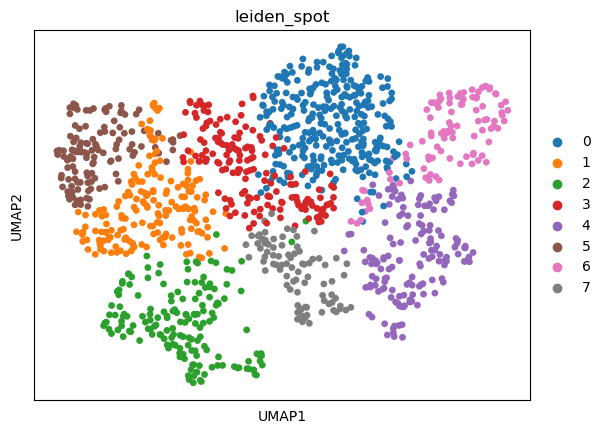

In [15]:
sc.pl.umap(adata,color='leiden_spot')

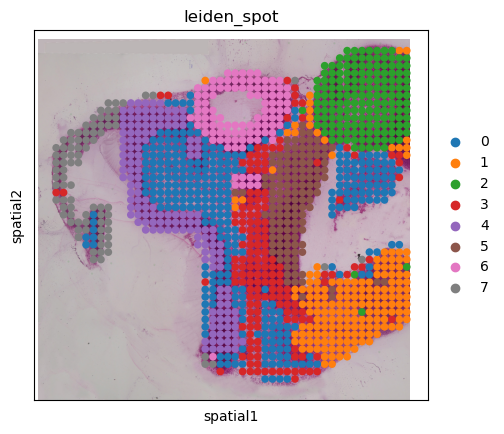

In [16]:
sc.pl.spatial(adata,color='leiden_spot',s=15)

In [17]:
adata.write('./MISAR_out/adata_speed.h5ad')